## Feature Engineering

In [2]:
# Load libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned, merged dataset from Step 3
df = pd.read_csv('data/clean/master_eda.csv', parse_dates=['date'], index_col='date')
print(df.shape)
df.head()

(255, 10)


,jkm_price,henry_price,ttf_price,USEP,lng_import_tonnes,png_import_tonnes,lng_outlier_flag,total_gas_tonnes,lng_share,png_share
date,,,,,,,,,,
2005-01-01,5.82,6.152000,5.06,78.6,NaN,NaN,NaN,NaN,NaN,NaN
2005-02-01,6.10,6.138421,5.06,83.6,NaN,NaN,NaN,NaN,NaN,NaN
2005-03-01,6.46,6.955455,5.06,97.7,NaN,NaN,NaN,NaN,NaN,NaN
2005-04-01,7.04,7.175714,5.51,99.8,NaN,NaN,NaN,NaN,NaN,NaN
2005-05-01,7.22,6.473810,5.51,113.5,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.tail()

,jkm_price,henry_price,ttf_price,USEP,lng_import_tonnes,png_import_tonnes,lng_outlier_flag,total_gas_tonnes,lng_share,png_share
date,,,,,,,,,,
2025-11-01,11.067,4.463500,10.355,139.7,465497.0,436755.0,0.0,902252.0,0.5159,0.4841
2025-12-01,9.910,4.431364,9.460,95.1,639810.0,433558.0,0.0,1073368.0,0.5961,0.4039
2026-01-01,10.435,4.144545,11.987,118.6,274173.0,425751.0,0.0,699924.0,0.3917,0.6083
2026-02-01,10.752,3.147500,11.190,132.9,412006.0,479962.0,0.0,891968.0,0.4619,0.5381
2026-03-01,20.812,3.035909,17.670,160.4,499947.0,422160.0,0.0,922107.0,0.5422,0.4578


In [5]:
# Lag features - JKM and TTF are highly correlated (0.91). Lagged price features will capture momentum

# Price lags — 1, 3, 6, 12 months
for lag in [1, 3, 6, 12]:
    df[f'jkm_lag_{lag}'] = df['jkm_price'].shift(lag)
    df[f'ttf_lag_{lag}'] = df['ttf_price'].shift(lag)

# Rolling averages — smooth out noise
df['jkm_rolling_3m'] = df['jkm_price'].rolling(3).mean()
df['jkm_rolling_6m'] = df['jkm_price'].rolling(6).mean()
df['jkm_rolling_12m'] = df['jkm_price'].rolling(12).mean()

In [6]:
# Spread features

df['jkm_ttf_spread'] = df['jkm_price'] - df['ttf_price']
df['jkm_hh_spread']  = df['jkm_price'] - df['henry_price']

In [7]:
# Calendar / Cyclical Features

df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year

# Encode month cyclically — avoids treating Dec (12) as far from Jan (1)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [8]:
# Supply Mix Features

df['total_gas'] = df['png_import_tonnes'] + df['lng_import_tonnes']
df['lng_share'] = df['lng_import_tonnes'] / df['total_gas']  # already in your dataset
df['lng_yoy_growth'] = df['lng_import_tonnes'].pct_change(12)

In [9]:
# Outlier / Regime Flag

df['crisis_flag'] = ((df.index.year == 2022)).astype(int)
df['lng_outlier_flag'] = (df['lng_import_tonnes'] > df['lng_import_tonnes'].quantile(0.99)).astype(int)

In [11]:
# Drop NaNs from Lags & Save

df_clean = df.dropna()
print(f"Rows before: {len(df)}, after dropping NaN from lags: {len(df_clean)}")
df_clean.to_csv('data/clean/04_features.csv')

Rows before: 255, after dropping NaN from lags: 147


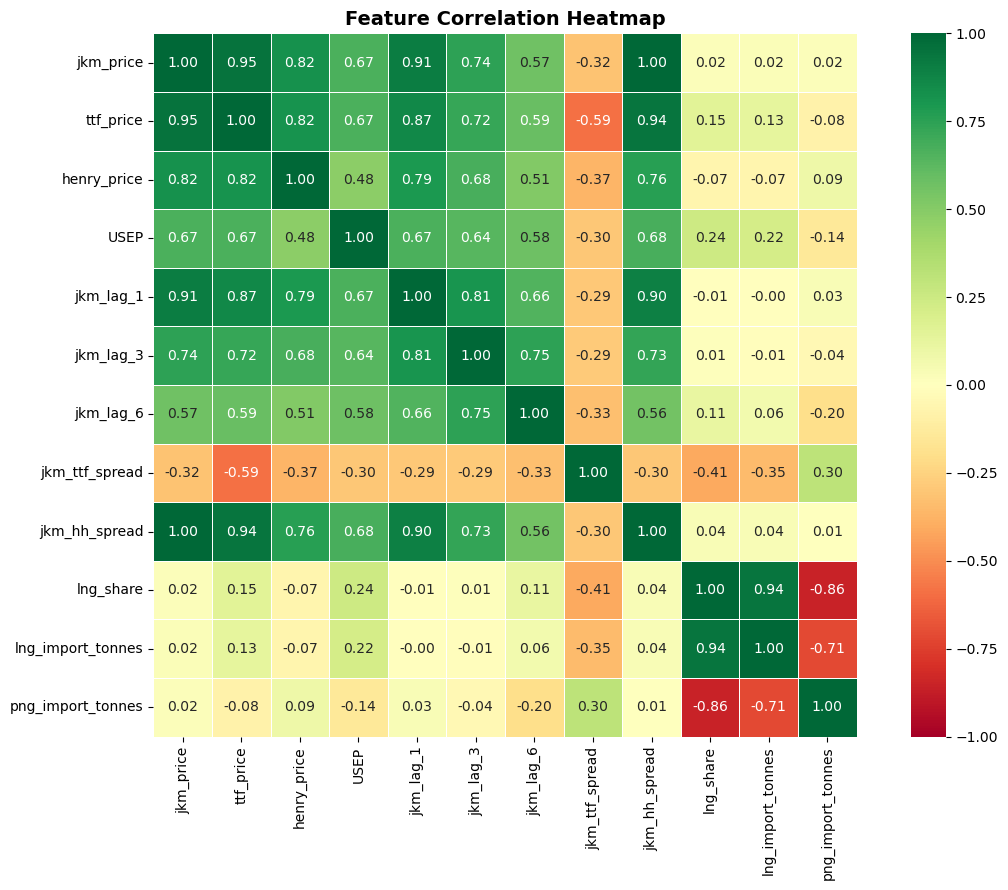


Top correlations with JKM price:
jkm_price            1.000000
jkm_hh_spread        0.995253
ttf_price            0.952587
jkm_lag_1            0.909118
henry_price          0.822424
jkm_lag_3            0.742415
USEP                 0.669378
jkm_lag_6            0.569091
lng_import_tonnes    0.023763
lng_share            0.022166
png_import_tonnes    0.019277
jkm_ttf_spread      -0.318786


In [14]:
# Correlation Heatmap

df = pd.read_csv('data/clean/04_features.csv', parse_dates=['date'], index_col='date')

feature_cols = ['jkm_price', 'ttf_price', 'henry_price', 'USEP',
                'jkm_lag_1', 'jkm_lag_3', 'jkm_lag_6',
                'jkm_ttf_spread', 'jkm_hh_spread',
                'lng_share', 'lng_import_tonnes', 'png_import_tonnes']

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/04_correlation_heatmap.png', dpi=150)
plt.show()

print("\nTop correlations with JKM price:")
print(corr['jkm_price'].sort_values(ascending=False).to_string())

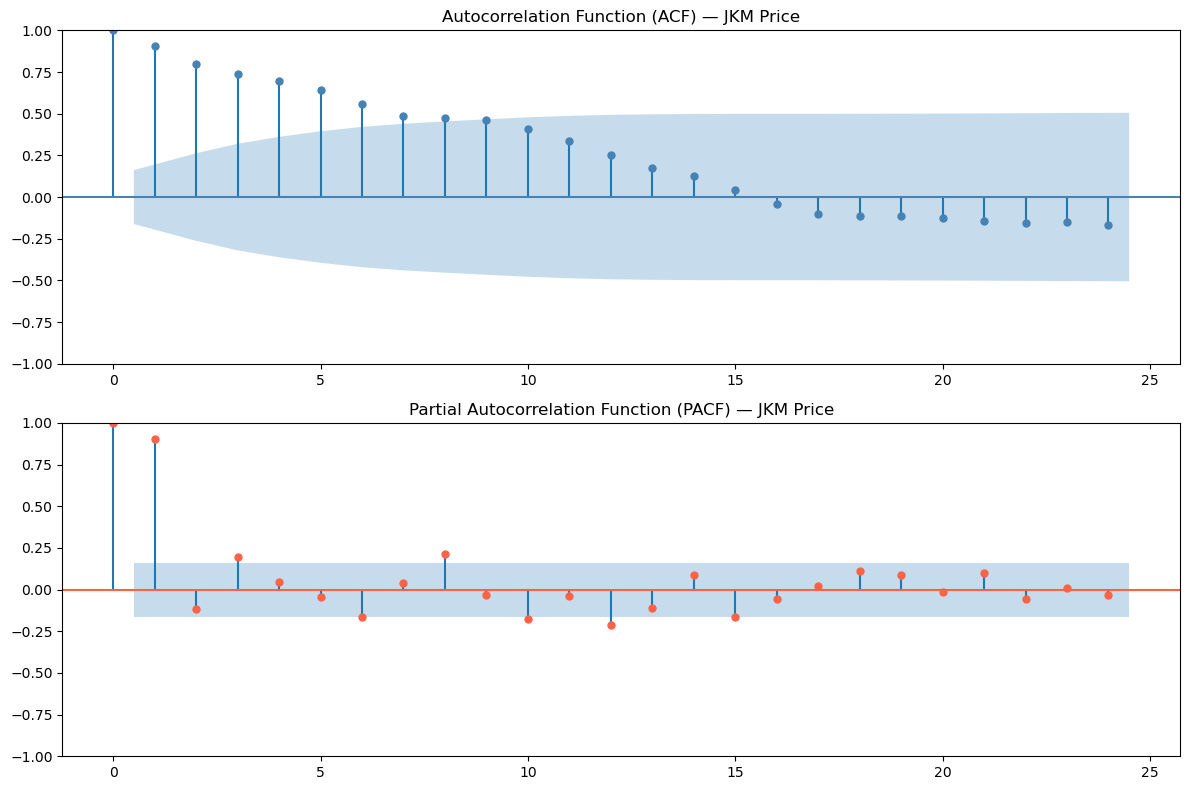

In [15]:
# ACF & PACF Plots (Lag Selection)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['jkm_price'].dropna(), lags=24, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF) — JKM Price')

plot_pacf(df['jkm_price'].dropna(), lags=24, ax=axes[1], color='tomato', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) — JKM Price')

plt.tight_layout()
plt.savefig('charts/04_acf_pacf.png', dpi=150)
plt.show()

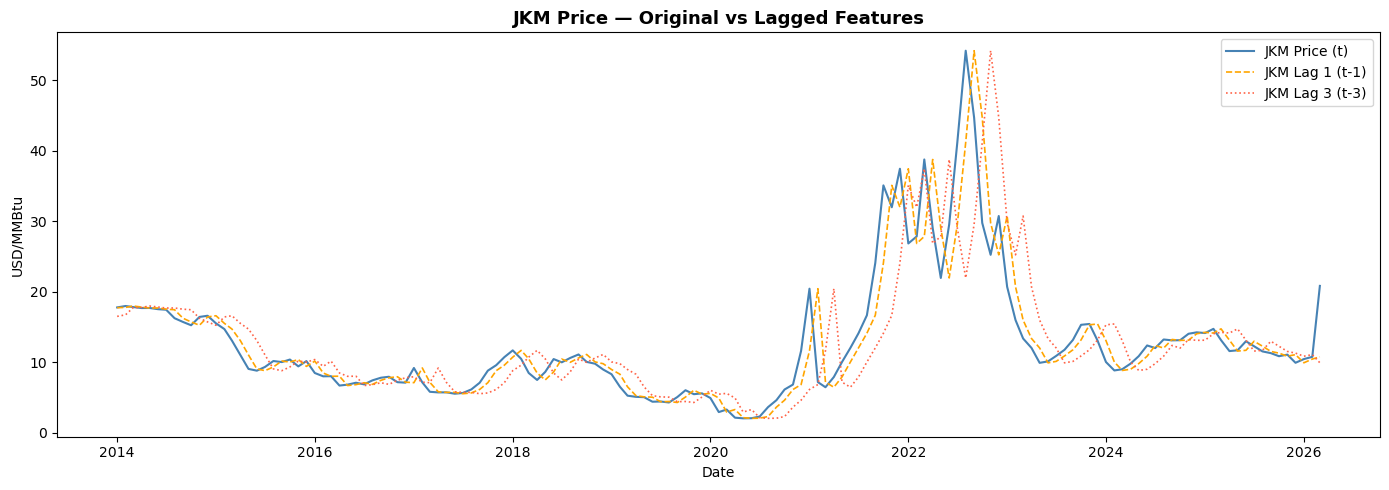

In [16]:
#Lag Feature Validation (Original vs Lagged Overlay)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['jkm_price'], label='JKM Price (t)', color='steelblue', lw=1.5)
ax.plot(df.index, df['jkm_lag_1'], label='JKM Lag 1 (t-1)', color='orange', lw=1.2, linestyle='--')
ax.plot(df.index, df['jkm_lag_3'], label='JKM Lag 3 (t-3)', color='tomato', lw=1.2, linestyle=':')

ax.set_title('JKM Price — Original vs Lagged Features', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('USD/MMBtu')
ax.legend()
plt.tight_layout()
plt.savefig('charts/04_lag_validation.png', dpi=150)
plt.show()

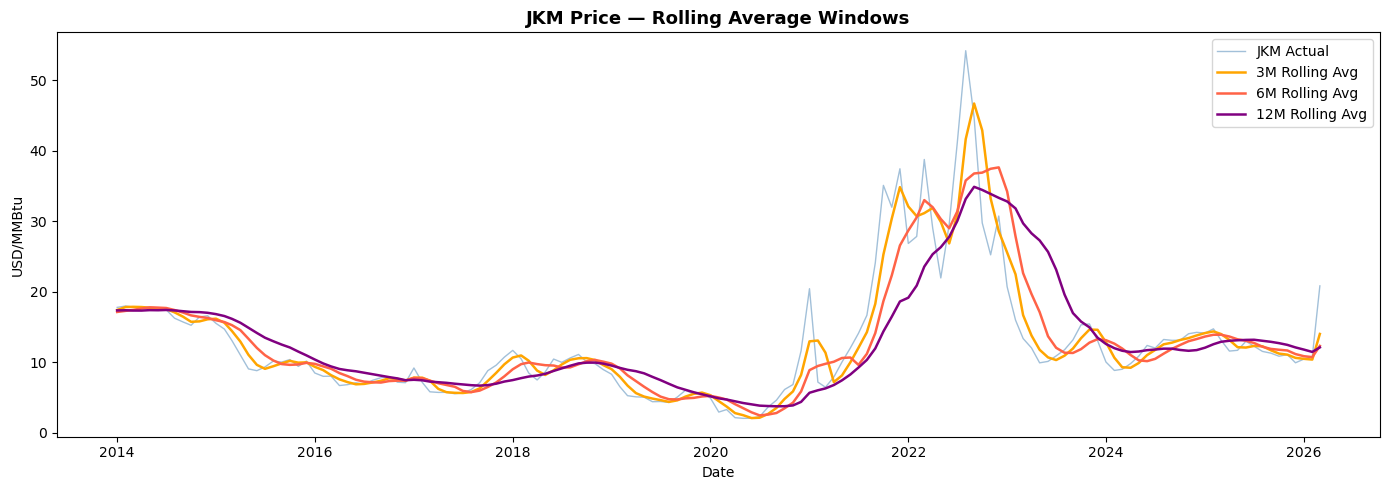

In [17]:
# Rolling Mean Overlay

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['jkm_price'], label='JKM Actual', color='steelblue', alpha=0.5, lw=1)
ax.plot(df.index, df['jkm_rolling_3m'], label='3M Rolling Avg', color='orange', lw=1.8)
ax.plot(df.index, df['jkm_rolling_6m'], label='6M Rolling Avg', color='tomato', lw=1.8)
ax.plot(df.index, df['jkm_rolling_12m'], label='12M Rolling Avg', color='purple', lw=1.8)

ax.set_title('JKM Price — Rolling Average Windows', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('USD/MMBtu')
ax.legend()
plt.tight_layout()
plt.savefig('charts/04_rolling_means.png', dpi=150)
plt.show()

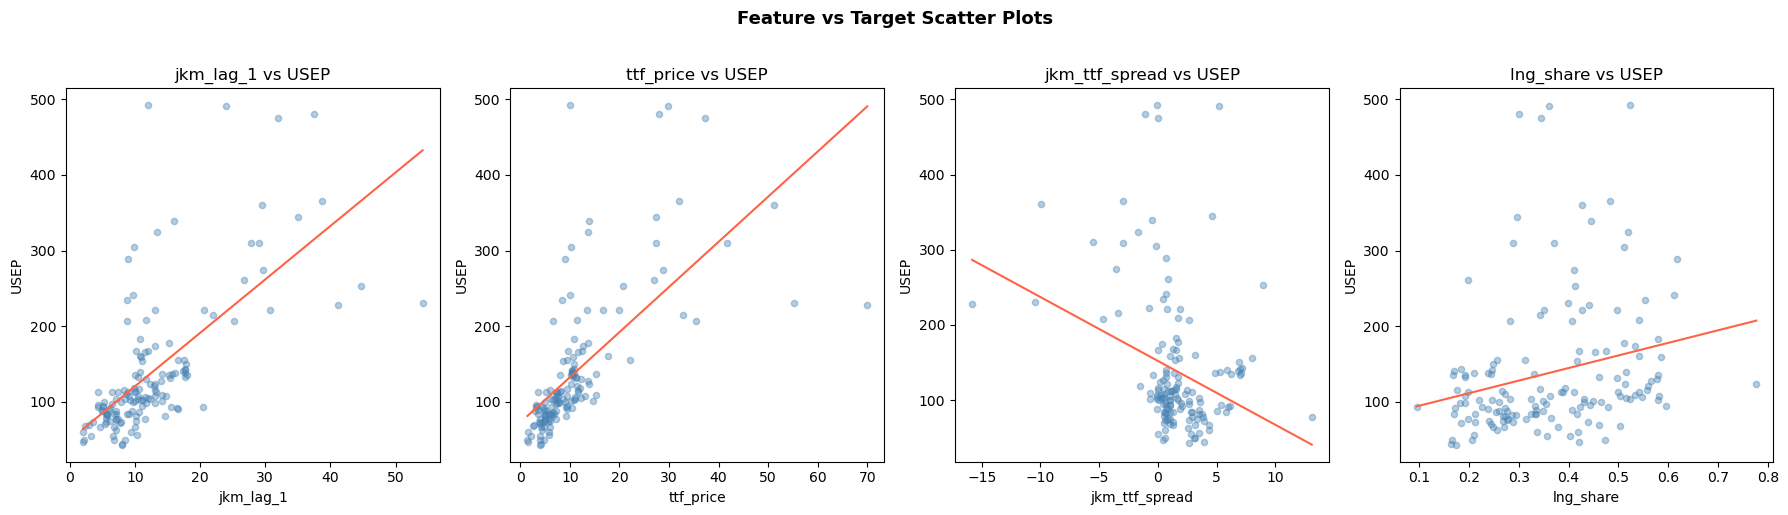

In [18]:
# Scatter: Feature vs Target

features_to_check = ['jkm_lag_1', 'ttf_price', 'jkm_ttf_spread', 'lng_share']
target = 'USEP'

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, feat in zip(axes, features_to_check):
    ax.scatter(df[feat], df[target], alpha=0.4, s=20, color='steelblue')
    # Trend line
    m, b = np.polyfit(df[feat].dropna(), df[target][df[feat].notna()], 1)
    x_range = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_range, m * x_range + b, color='tomato', lw=1.5)
    ax.set_xlabel(feat)
    ax.set_ylabel(target)
    ax.set_title(f'{feat} vs {target}')

plt.suptitle('Feature vs Target Scatter Plots', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/04_scatter_features_vs_target.png', dpi=150)
plt.show()

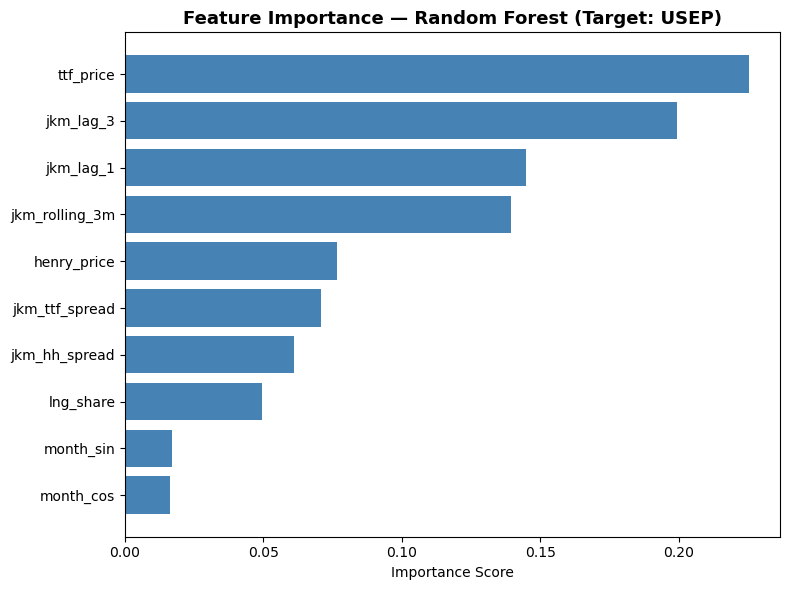

In [19]:
# Feature Importance (Random Forest)

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

feat_cols = ['jkm_lag_1', 'jkm_lag_3', 'ttf_price', 'henry_price',
             'jkm_ttf_spread', 'jkm_hh_spread', 'lng_share',
             'month_sin', 'month_cos', 'jkm_rolling_3m']

df_model = df[feat_cols + ['USEP']].dropna()
X = df_model[feat_cols]
y = df_model['USEP']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({'feature': feat_cols,
                               'importance': rf.feature_importances_}).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('Feature Importance — Random Forest (Target: USEP)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/04_feature_importance.png', dpi=150)
plt.show()

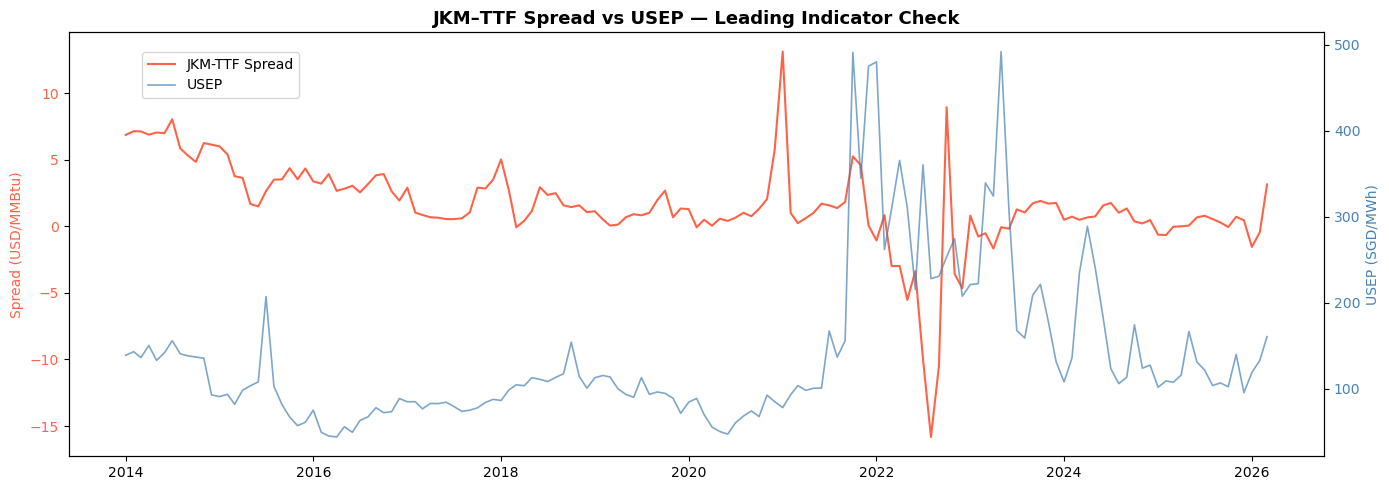

In [20]:
# Dual-Axis: Spread vs USEP (Leading Indicator Check)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(df.index, df['jkm_ttf_spread'], color='tomato', lw=1.5, label='JKM-TTF Spread')
ax1.set_ylabel('Spread (USD/MMBtu)', color='tomato')
ax1.tick_params(axis='y', labelcolor='tomato')

ax2 = ax1.twinx()
ax2.plot(df.index, df['USEP'], color='steelblue', lw=1.2, alpha=0.7, label='USEP')
ax2.set_ylabel('USEP (SGD/MWh)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('JKM–TTF Spread vs USEP — Leading Indicator Check', fontsize=13, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('charts/04_spread_vs_usep.png', dpi=150)
plt.show()

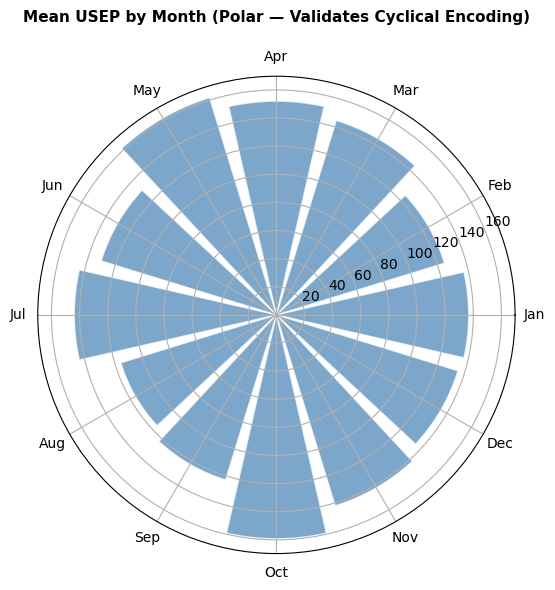

In [22]:
# Cyclical Month Encoding Visual

theta = np.linspace(0, 2 * np.pi, 12, endpoint=False)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_usep = df.groupby('month')['USEP'].mean().values

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
bars = ax.bar(theta, monthly_usep, width=0.45, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_xticks(theta)
ax.set_xticklabels(month_names)
ax.set_title('Mean USEP by Month (Polar — Validates Cyclical Encoding)',
             fontsize=11, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('charts/04_polar_month.png', dpi=150)
plt.show()